# Train one stage (helpful)
Train Qwen2.5-1.5B-Instruct with DPO + 4-bit QLoRA on the 2,000 helpful training pairs, then check it learned.

**Needs a GPU:** in Colab, Runtime → Change runtime type → **L4** (or A100).

What we want to find out:
1. Does training work at all? (loss goes down from 0.69)
2. How long does one stage take, and how much GPU memory? (this tells us if 1,024 tokens is affordable)
3. Did it learn? (the model should prefer the chosen answers on **helpful val** pairs it has never seen)

In [1]:
import os, sys, getpass

if os.path.exists("/content"):   # on Colab: get the latest code + data from GitHub
    if not os.path.exists("/content/mfr-dpo"):
        !git clone -q https://github.com/prabudhd2003/mfr-dpo.git /content/mfr-dpo
    !git -C /content/mfr-dpo pull -q
    !pip install -q peft bitsandbytes
    REPO = "/content/mfr-dpo"
else:
    REPO = ".."

sys.path.insert(0, f"{REPO}/src")
import importlib, mfr_data, mfr_dpo
importlib.reload(mfr_data)
importlib.reload(mfr_dpo)

import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch the runtime to a GPU")

GPU: NVIDIA L4


In [2]:
splits = mfr_data.load_splits(f"{REPO}/data")
train = splits["helpful"]["train"]
print(len(train), "helpful training pairs")

2000 helpful training pairs


## 1. Quick test (100 pairs, a few minutes)
Just checks that everything runs and the loss starts going down from 0.69 (= the model has no preference yet).

In [3]:
# optional 
os.environ["HF_TOKEN"] = getpass.getpass("Paste your HF token: ")

In [4]:
model, tokenizer = mfr_dpo.load_model()
model.print_trainable_parameters()

quick = mfr_dpo.train_stage(model, tokenizer, train.head(100), log_every=1)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
step    1/7 | loss 0.693 | batch acc 0.00 | 0.4 min
step    2/7 | loss 0.693 | batch acc 0.00 | 0.7 min
step    3/7 | loss 0.686 | batch acc 0.62 | 1.1 min
step    4/7 | loss 0.711 | batch acc 0.31 | 1.5 min
step    5/7 | loss 0.672 | batch acc 0.56 | 2.0 min
step    6/7 | loss 0.687 | batch acc 0.56 | 2.3 min
step    7/7 | loss 0.645 | batch acc 1.00 | 2.4 min

Done: 100 pairs in 2.4 min, peak GPU memory 12.5 GB


## 2. Full stage (2,000 pairs)
We reload the model first so this run starts from scratch, not from the quick test.

In [5]:
del model
torch.cuda.empty_cache()
model, tokenizer = mfr_dpo.load_model()

BETA, LR = 0.1, 5e-5   # starting guesses; we tune them in the pilot
history = mfr_dpo.train_stage(model, tokenizer, train, beta=BETA, lr=LR)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

step   10/125 | loss 0.687 | batch acc 0.62 | 3.8 min
step   20/125 | loss 0.612 | batch acc 0.69 | 7.6 min
step   30/125 | loss 0.618 | batch acc 0.69 | 11.3 min
step   40/125 | loss 0.643 | batch acc 0.69 | 15.3 min
step   50/125 | loss 0.566 | batch acc 0.69 | 19.2 min
step   60/125 | loss 0.625 | batch acc 0.69 | 22.9 min
step   70/125 | loss 0.552 | batch acc 0.69 | 27.0 min
step   80/125 | loss 0.582 | batch acc 0.69 | 31.0 min
step   90/125 | loss 0.630 | batch acc 0.56 | 35.1 min
step  100/125 | loss 0.558 | batch acc 0.69 | 38.8 min
step  110/125 | loss 0.508 | batch acc 0.81 | 42.8 min
step  120/125 | loss 0.662 | batch acc 0.62 | 46.7 min
step  125/125 | loss 0.490 | batch acc 0.75 | 48.7 min

Done: 2000 pairs in 48.7 min, peak GPU memory 12.6 GB


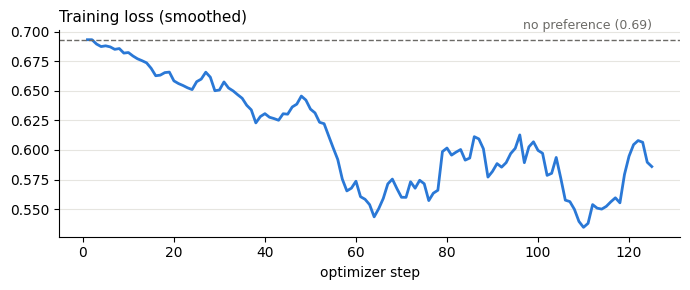

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["step"], history["loss"].rolling(10, min_periods=1).mean(), color="#2a78d6", linewidth=2)
ax.axhline(0.693, color="#6b6a66", linestyle="--", linewidth=1)
ax.text(history["step"].max(), 0.70, "no preference (0.69)", ha="right", va="bottom", fontsize=9, color="#6b6a66")
ax.set_title("Training loss (smoothed)", loc="left", fontsize=11)
ax.set_xlabel("optimizer step")
ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Did it learn?
For every **val** pair we compute the margin: how much more the trained model prefers the chosen answer
than the untrained model did. Before training every margin is exactly 0.

* **helpful**: should clearly go up (accuracy well above 50%). This is what we just trained on.
* **safe / quality**: not trained yet. This is the "before" picture for measuring forgetting later.

In [8]:
import time
import pandas as pd

results = {}
for name in ["helpful", "safe", "quality"]:
    df = splits[name]["val"]
    start = time.time()
    parts = []
    for i in range(0, len(df), 20):
        parts.append(mfr_dpo.score_margins(model, tokenizer, df.iloc[i:i + 20], beta=BETA))
        print(f"\r{name}: {min(i + 20, len(df))}/{len(df)} pairs | {time.time() - start:.0f}s", end="")
    print()
    m = pd.concat(parts)
    results[name] = {"accuracy (margin > 0)": f"{100 * (m > 0).mean():.0f}%",
                     "mean margin": round(m.mean(), 4)}
pd.DataFrame(results)

helpful: 200/200 pairs | 163s
safe: 200/200 pairs | 62s
quality: 200/200 pairs | 158s


,helpful,safe,quality
accuracy (margin > 0),58%,44%,71%
mean margin,0.005,-0.005,0.0072


In [9]:
print(results)

{'helpful': {'accuracy (margin > 0)': '58%', 'mean margin': np.float64(0.005)}, 'safe': {'accuracy (margin > 0)': '44%', 'mean margin': np.float64(-0.005)}, 'quality': {'accuracy (margin > 0)': '71%', 'mean margin': np.float64(0.0072)}}


## 4. Save the adapter (optional)
The adapter is small (about 70 MB). Colab deletes everything when the session ends, so save it to the team Drive
if you want to keep it. In VS Code, mount Drive first with Command Palette → "Colab: Mount Google Drive to Server".

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
DRIVE_DIR = "/content/drive/MyDrive/CSCI544/mfr-dpo"
out = f"{DRIVE_DIR}/adapters/helpful_one_stage"
os.makedirs(out, exist_ok=True)

model.save_pretrained(out)                                   # the trained adapter (~70 MB)
history.to_csv(f"{out}/history.csv", index=False)            # loss per step
pd.DataFrame(results).to_csv(f"{out}/val_results.csv")       # the accuracy table

print(os.listdir(out))

['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'history.csv', 'val_results.csv']
